In [1]:
import faiss
import numpy as np
from sentence_transformers import SentenceTransformer, InputExample, losses
from datasets import load_dataset
from torch.utils.data import DataLoader

/opt/anaconda3/envs/Huggingface/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Embedding sentences

In [2]:
# Load a sentence-transformers model
model = SentenceTransformer("all-MiniLM-L6-v2")

# Example sentences
sentences = [
    "Artificial Intelligence is transforming the world.",
    "Machine learning is a subset of AI.",
    "Deep learning uses neural networks.",
    "Natural language processing enables AI to understand text.",
    "The capital of France is Paris.",
    "Eiffel Tower is a famous landmark in Paris.",
]

# Get sentence embeddings
sentence_embeddings = model.encode(sentences)

print("Sentence embeddings shape:", sentence_embeddings.shape)  # Output: (2, 384)

Sentence embeddings shape: (6, 384)


In this simple exmaple, the output shape is (2, 384) which means we have 2 sentences and each sentence is represented by a 384-dimensional vector.

# Visualizing Sentence Embeddings

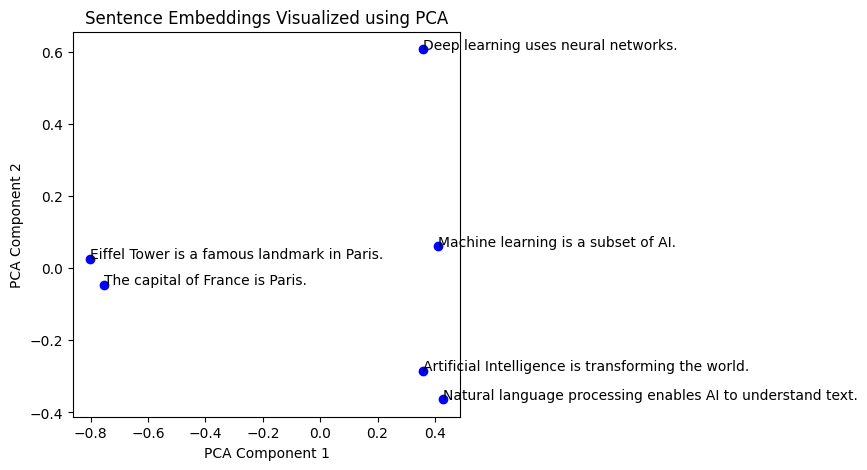

In [3]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

# Reduce embeddings to 2D using PCA
pca = PCA(n_components=2)
reduced_embeddings = pca.fit_transform(sentence_embeddings)

# Plot the embeddings
plt.figure(figsize=(5, 5))
plt.scatter(reduced_embeddings[:, 0], reduced_embeddings[:, 1], color="blue")

# Add labels
for i, sentence in enumerate(sentences):
    plt.annotate(sentence, (reduced_embeddings[i, 0], reduced_embeddings[i, 1]))

plt.title("Sentence Embeddings Visualized using PCA")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.show()


huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


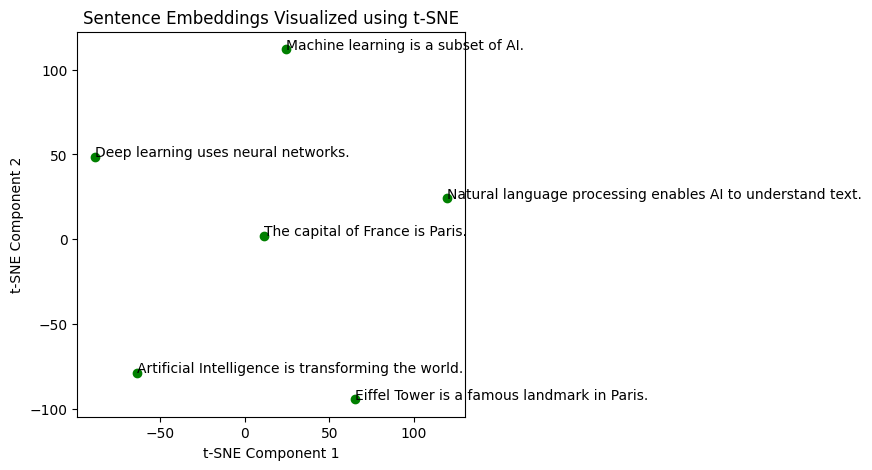

In [4]:
from sklearn.manifold import TSNE

# Reduce dimensions with t-SNE
tsne = TSNE(n_components=2, perplexity=5, random_state=42)
tsne_embeddings = tsne.fit_transform(sentence_embeddings)

# Plot embeddings
plt.figure(figsize=(5, 5))
plt.scatter(tsne_embeddings[:, 0], tsne_embeddings[:, 1], color="green")

# Add labels
for i, sentence in enumerate(sentences):
    plt.annotate(sentence, (tsne_embeddings[i, 0], tsne_embeddings[i, 1]))

plt.title("Sentence Embeddings Visualized using t-SNE")
plt.xlabel("t-SNE Component 1")
plt.ylabel("t-SNE Component 2")
plt.show()


In [ ]:
import umap

# Reduce dimensions with UMAP
umap_embeddings = umap.UMAP(n_components=2).fit_transform(sentence_embeddings)

# Plot embeddings
plt.figure(figsize=(5, 5))
plt.scatter(umap_embeddings[:, 0], umap_embeddings[:, 1], color="red")

# Add labels
for i, sentence in enumerate(sentences):
    plt.annotate(sentence, (umap_embeddings[i, 0], umap_embeddings[i, 1]))

plt.title("Sentence Embeddings Visualized using UMAP")
plt.xlabel("UMAP Component 1")
plt.ylabel("UMAP Component 2")
plt.show()


# 3D Visualization

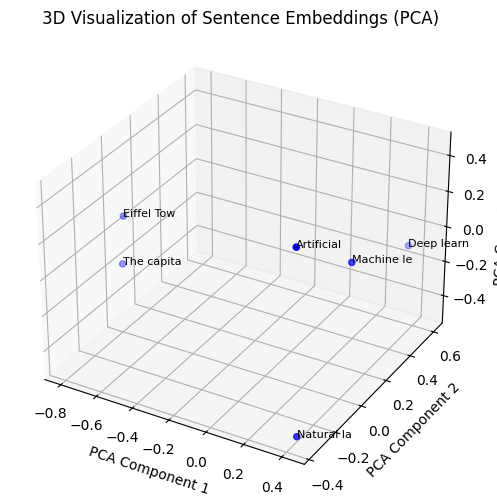

In [9]:
# Reduce dimensions to 3D using PCA
pca = PCA(n_components=3)
reduced_embeddings = pca.fit_transform(sentence_embeddings)

# 3D Plot
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection="3d")

ax.scatter(
    reduced_embeddings[:, 0], reduced_embeddings[:, 1], reduced_embeddings[:, 2], c="blue"
)

# Annotate points
for i, sentence in enumerate(sentences):
    ax.text(reduced_embeddings[i, 0], reduced_embeddings[i, 1], reduced_embeddings[i, 2], sentence[:10], fontsize=8)

ax.set_title("3D Visualization of Sentence Embeddings (PCA)")
ax.set_xlabel("PCA Component 1")
ax.set_ylabel("PCA Component 2")
ax.set_zlabel("PCA Component 3")
plt.show()

# Storing Embedding Vectors

In [10]:

# Create a FAISS index (L2 distance)
d = sentence_embeddings.shape[1]  # Dimension of embeddings
index = faiss.IndexFlatL2(d)
index.add(np.array(sentence_embeddings).astype("float32"))

# Search for the closest sentence
query = model.encode(["Find similar text."]).astype("float32")
_, indices = index.search(query, k=1)
print("Most similar sentence:", sentences[indices[0][0]])


Most similar sentence: Natural language processing enables AI to understand text.


# Fine-Tune

In [11]:
# Load dataset (or use your own)
dataset = load_dataset("quora", split="train[:5000]")  # Small subset for testing

# Prepare training examples
train_samples = [InputExample(texts=[row["questions"]["text"], row["questions"]["text"]]) for row in dataset]

# Load pre-trained model
model = SentenceTransformer("all-MiniLM-L6-v2")

# Define loss function
train_dataloader = DataLoader(train_samples, batch_size=16, shuffle=True)
train_loss = losses.MultipleNegativesRankingLoss(model)

# Fine-tune the model
model.fit(train_objectives=[(train_dataloader, train_loss)], epochs=1, warmup_steps=100)

# Save locally
model.save("fine_tuned_model")


C:\Users\jiabo\AppData\Local\anaconda3\envs\HuggingFace\Lib\site-packages\huggingface_hub\file_download.py:140: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\jiabo\.cache\huggingface\hub\datasets--quora. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


ValueError: The repository for quora contains custom code which must be executed to correctly load the dataset. You can inspect the repository content at https://hf.co/datasets/quora.
Please pass the argument `trust_remote_code=True` to allow custom code to be run.